# My Project Title

[Open in Colab](https://colab.research.google.com/github/https://github.com/akshatjain632/blob/main/RL_Project_rewards_experiments_4.ipynb)

In [ ]:
# ============================================================
# CELL 1 — Installs + Imports
# ============================================================
%pip -q install gymnasium torch matplotlib pandas numpy

import math
import random
from dataclasses import dataclass
from typing import Dict, Tuple, Optional, List, Callable

import numpy as np
import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from IPython.display import display

print("All imports OK")
print("PyTorch version:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

All imports OK
PyTorch version: 2.10.0+cpu
Device: cpu


In [ ]:
# ============================================================
# CELL 2 — Plot Helpers
# ============================================================
ALGO_COLORS = {
    "Heuristic": "#555555",
    "PPO":        "#1f77b4",
    "A2C":        "#ff7f0e",
    "RecurrentPPO": "#2ca02c",
}

def smooth(y, k=10):
    y = np.asarray(y, dtype=float)
    if len(y) < k:
        return y
    out = np.convolve(y, np.ones(k) / k, mode="valid")
    pad = np.full(k - 1, np.nan)
    return np.concatenate([pad, out])

def normalize_x(xs):
    xs = np.asarray(xs, dtype=float)
    if len(xs) <= 1:
        return xs
    mn, mx = xs.min(), xs.max()
    return (xs - mn) / (mx - mn + 1e-9)

def plot_learning_curves(curves: dict, title: str, xlabel: str,
                         ylabel: str = "Mean Return", smooth_k: int = 3):
    """curves = {label: (x_array, y_array)}"""
    fig, ax = plt.subplots(figsize=(8, 4))
    for label, (xs, ys) in curves.items():
        xs = np.asarray(xs, dtype=float)
        ys = np.asarray(ys, dtype=float)
        color = ALGO_COLORS.get(label.split()[0], None)
        ys_s = smooth(ys, k=smooth_k)
        ax.plot(xs, ys_s, label=label, color=color)
        ax.fill_between(xs, ys_s, alpha=0.08, color=color)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def boxplot_compare(title: str, results_dict: dict):
    fig, ax = plt.subplots(figsize=(8, 4))
    data   = [np.asarray(v, dtype=float) for v in results_dict.values()]
    labels = list(results_dict.keys())
    bp = ax.boxplot(data, labels=labels, showmeans=True, patch_artist=True)
    for patch, lbl in zip(bp["boxes"], labels):
        patch.set_facecolor(ALGO_COLORS.get(lbl, "#aaaaaa"))
        patch.set_alpha(0.6)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Return")
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

def bar_compare(title: str, summary_dict: dict, metric: str = "mean_return"):
    labels = list(summary_dict.keys())
    vals   = [summary_dict[l][metric] for l in labels]
    errs   = [summary_dict[l].get("std_return", 0) for l in labels]
    colors = [ALGO_COLORS.get(l, "#aaaaaa") for l in labels]
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(labels, vals, yerr=errs, color=colors, alpha=0.75, capsize=5)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel(metric.replace("_", " ").title())
    ax.grid(axis="y", alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{v:.1f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

def pivot_heatmap(df: pd.DataFrame, metric: str = "mean_return"):
    p = df.pivot_table(index="reward_setting", columns="algo",
                       values=metric, aggfunc="mean")
    fig, ax = plt.subplots(figsize=(9, 4))
    im = ax.imshow(p.values, aspect="auto", cmap="RdYlGn")
    ax.set_xticks(range(len(p.columns))); ax.set_xticklabels(p.columns, rotation=20)
    ax.set_yticks(range(len(p.index)));   ax.set_yticklabels(p.index)
    for i in range(p.shape[0]):
        for j in range(p.shape[1]):
            val = p.values[i, j]
            ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                    fontsize=9, color="black")
    plt.colorbar(im, ax=ax, label=metric)
    ax.set_title(f"Heatmap — {metric}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()
    return p

print("Plot helpers OK")

Plot helpers OK


In [ ]:
# ============================================================
# CELL 3 — Environment with 5 New Reward Functions
# ============================================================
@dataclass
class SingleUAVConfig:
    num_customers:     int   = 5
    num_chargers:      int   = 1
    map_size:          Tuple[float, float] = (100.0, 100.0)
    mission_time:      float = 500.0
    max_steps:         int   = 100
    battery_capacity:  float = 250.0
    battery_per_meter: float = 0.5
    drone_speed:       float = 15.0
    deadline_min:      float = 80.0
    deadline_max:      float = 250.0

    # reward_mode choices:
    #   "dist_normalized" | "completion_ratio" | "battery_aware"
    #   "time_pressure"   | "regret_based"
    reward_mode: str = "completion_ratio"

    # shared weights
    w_service:    float = 30.0
    w_complete:   float = 60.0
    w_infeasible: float = 10.0
    w_repeat:     float = 1.0
    w_tardiness:  float = 0.2
    w_step:       float = 0.0

    # dist_normalized
    w_dist_bonus:   float = 10.0   # max extra bonus for efficiency

    # battery_aware
    w_battery_pen:  float = 5.0    # penalty scale when battery critically low
    battery_low_thresh: float = 0.25  # fraction of capacity considered low

    # time_pressure
    w_time_late_mult: float = 2.5  # multiplier in last 30% of mission time

    # regret_based
    w_regret:     float = 3.0      # penalty per newly unreachable customer

    # charging
    charger_time_cost: float = 1.0
    recharge_rate:     float = 120.0

    deterministic_seed: int = 42

    def total_nodes(self) -> int:
        return 1 + self.num_customers + self.num_chargers


@dataclass
class ServiceNode:
    node_id:  int
    position: np.ndarray
    deadline: float


@dataclass
class ChargerNode:
    node_id:  int
    position: np.ndarray


class SingleUAVEnv(gym.Env):
    metadata = {"render_modes": ["human"]}

    def __init__(self, config: Optional[SingleUAVConfig] = None):
        super().__init__()
        self.config = config or SingleUAVConfig()
        self.rng = np.random.default_rng(self.config.deterministic_seed)

        self.service_nodes: Dict[int, ServiceNode] = {}
        self.charger_nodes: Dict[int, ChargerNode] = {}

        self.depot_position = np.array(self.config.map_size, dtype=np.float32) / 2.0
        self.node_positions  = np.zeros((self.config.total_nodes(), 2), dtype=np.float32)

        self.current_node    = 0
        self.battery         = self.config.battery_capacity
        self.time_remaining  = self.config.mission_time
        self.elapsed_time    = 0.0
        self.steps           = 0
        self.visited_mask    = np.zeros(self.config.num_customers, dtype=np.int8)

        # episode metrics
        self.ep_distance      = 0.0
        self.ep_energy        = 0.0
        self.ep_travel_time   = 0.0
        self.ep_tardiness     = 0.0
        self.ep_charger_visits= 0
        self.ep_infeasible    = 0
        self.ep_repeat_visits = 0

        self.observation_space = spaces.Dict({
            "agent":          spaces.Box(0.0, 1.0, shape=(3,),  dtype=np.float32),
            "visited":        spaces.MultiBinary(self.config.num_customers),
            "deadlines":      spaces.Box(0.0, 1.0, shape=(self.config.num_customers,), dtype=np.float32),
            "node_positions": spaces.Box(0.0, 1.0, shape=(self.config.total_nodes(), 2), dtype=np.float32),
        })
        self.action_space = spaces.Discrete(self.config.total_nodes())

        self._build_nodes()
        self._prev_visited_count = 0   # used by regret/completion rewards

    # ------------------------------------------------------------------
    # Setup
    # ------------------------------------------------------------------
    def seed(self, seed: int):
        self.rng = np.random.default_rng(seed)

    def _build_nodes(self):
        self.node_positions[0] = self.depot_position
        w, h = self.config.map_size

        self.service_nodes.clear()
        for i in range(self.config.num_customers):
            nid = 1 + i
            pos = self.rng.uniform([0, 0], [w, h]).astype(np.float32)
            ddl = float(self.rng.uniform(self.config.deadline_min, self.config.deadline_max))
            self.service_nodes[nid] = ServiceNode(nid, pos, ddl)
            self.node_positions[nid] = pos

        self.charger_nodes.clear()
        for j in range(self.config.num_chargers):
            nid = 1 + self.config.num_customers + j
            pos = self.rng.uniform([0, 0], [w, h]).astype(np.float32)
            self.charger_nodes[nid] = ChargerNode(nid, pos)
            self.node_positions[nid] = pos

    # ------------------------------------------------------------------
    # Helpers
    # ------------------------------------------------------------------
    def _get_obs(self):
        total = self.config.total_nodes()
        cur_norm  = float(self.current_node) / float(total - 1) if total > 1 else 0.0
        batt_frac = float(self.battery) / float(self.config.battery_capacity + 1e-9)
        time_frac = float(self.elapsed_time) / float(self.config.mission_time + 1e-9)

        w, h = self.config.map_size
        node_pos_norm = self.node_positions.copy()
        node_pos_norm[:, 0] /= w
        node_pos_norm[:, 1] /= h

        dmin, dmax = self.config.deadline_min, self.config.deadline_max
        deadlines = np.zeros(self.config.num_customers, dtype=np.float32)
        for i in range(self.config.num_customers):
            ddl = self.service_nodes[1 + i].deadline
            deadlines[i] = (ddl - dmin) / (dmax - dmin + 1e-9)

        return {
            "agent":          np.array([cur_norm, batt_frac, time_frac], dtype=np.float32),
            "visited":        self.visited_mask.astype(np.int8),
            "deadlines":      deadlines,
            "node_positions": node_pos_norm.astype(np.float32),
        }

    def _distance(self, a: int, b: int) -> float:
        return float(np.linalg.norm(self.node_positions[a] - self.node_positions[b]))

    def _travel_energy(self, dist: float) -> float:
        return dist * self.config.battery_per_meter

    def _travel_time(self, dist: float) -> float:
        return dist / (self.config.drone_speed + 1e-9)

    def get_action_mask(self) -> np.ndarray:
        n = self.config.total_nodes()
        mask = np.ones(n, dtype=np.bool_)
        mask[self.current_node] = False
        for a in range(n):
            if not mask[a]:
                continue
            dist = self._distance(self.current_node, a)
            e = self._travel_energy(dist)
            t = self._travel_time(dist)
            if e > self.battery + 1e-9 or t > self.time_remaining + 1e-9 or t <= 0:
                mask[a] = False
        return mask

    def _count_reachable(self) -> int:
        """Count how many unvisited customers are currently reachable."""
        count = 0
        for i in range(self.config.num_customers):
            if self.visited_mask[i] == 1:
                continue
            nid  = 1 + i
            dist = self._distance(self.current_node, nid)
            if (self._travel_energy(dist) <= self.battery + 1e-9 and
                    self._travel_time(dist) <= self.time_remaining + 1e-9):
                count += 1
        return count

    # ------------------------------------------------------------------
    # ==================  5 REWARD FUNCTIONS  ==========================
    # ------------------------------------------------------------------

    def _reward_dist_normalized(self, served_new, repeated, infeasible,
                                 completed_and_depot, dist, travel_t,
                                 energy, tardiness, charged):
        """
        Reward efficient travel: bonus scales inversely with distance taken
        to reach the customer relative to the map diagonal.
        Short hop to far customer = high bonus. Long detour = low bonus.
        """
        cfg = self.config
        if infeasible:
            return -cfg.w_infeasible
        r = -cfg.w_step
        if repeated:
            r -= cfg.w_repeat
        if served_new:
            diag = math.hypot(*cfg.map_size)
            efficiency = 1.0 - min(dist / (diag + 1e-9), 1.0)  # 1=close, 0=far
            r += cfg.w_service + cfg.w_dist_bonus * efficiency
            r -= cfg.w_tardiness * tardiness
        if completed_and_depot:
            r += cfg.w_complete
        return r

    def _reward_completion_ratio(self, served_new, repeated, infeasible,
                                  completed_and_depot, dist, travel_t,
                                  energy, tardiness, charged):
        """
        Quadratically increasing bonus as completion ratio rises.
        Encourages finishing ALL customers, not just a few.
        """
        cfg = self.config
        if infeasible:
            return -cfg.w_infeasible
        r = -cfg.w_step
        if repeated:
            r -= cfg.w_repeat
        if served_new:
            ratio = float(self.visited_mask.sum()) / (cfg.num_customers + 1e-9)
            r += cfg.w_service * (1.0 + ratio ** 2)   # quadratic boost
            r -= cfg.w_tardiness * tardiness
        if completed_and_depot:
            r += cfg.w_complete
        return r

    def _reward_battery_aware(self, served_new, repeated, infeasible,
                               completed_and_depot, dist, travel_t,
                               energy, tardiness, charged):
        """
        Adds a continuous penalty when battery is low and no charger was visited.
        Forces the agent to plan charging proactively.
        """
        cfg = self.config
        if infeasible:
            return -cfg.w_infeasible
        r = -cfg.w_step
        if repeated:
            r -= cfg.w_repeat

        # battery penalty: kicks in below threshold, grows as battery drops
        batt_frac = self.battery / (cfg.battery_capacity + 1e-9)
        if batt_frac < cfg.battery_low_thresh and not charged:
            severity = (cfg.battery_low_thresh - batt_frac) / (cfg.battery_low_thresh + 1e-9)
            r -= cfg.w_battery_pen * severity

        if served_new:
            r += cfg.w_service
            r -= cfg.w_tardiness * tardiness
        if completed_and_depot:
            r += cfg.w_complete
        return r

    def _reward_time_pressure(self, served_new, repeated, infeasible,
                               completed_and_depot, dist, travel_t,
                               energy, tardiness, charged):
        """
        Service reward multiplier increases in the last 30% of mission time.
        Creates urgency to finish customers before time runs out.
        """
        cfg = self.config
        if infeasible:
            return -cfg.w_infeasible
        r = -cfg.w_step
        if repeated:
            r -= cfg.w_repeat
        if served_new:
            time_progress = self.elapsed_time / (cfg.mission_time + 1e-9)
            # multiplier ramps from 1x to w_time_late_mult in last 30%
            if time_progress >= 0.70:
                ramp = (time_progress - 0.70) / 0.30          # 0 → 1
                mult = 1.0 + (cfg.w_time_late_mult - 1.0) * ramp
            else:
                mult = 1.0
            r += cfg.w_service * mult
            r -= cfg.w_tardiness * tardiness
        if completed_and_depot:
            r += cfg.w_complete
        return r

    def _reward_regret_based(self, served_new, repeated, infeasible,
                              completed_and_depot, dist, travel_t,
                              energy, tardiness, charged,
                              reachable_before: int):
        """
        Penalises the agent for each customer that became unreachable this step.
        Dense signal directly punishing poor planning.
        """
        cfg = self.config
        if infeasible:
            return -cfg.w_infeasible
        r = -cfg.w_step
        if repeated:
            r -= cfg.w_repeat

        reachable_after = self._count_reachable()
        # how many unvisited customers did we *lose* access to?
        newly_lost = max(0, reachable_before - reachable_after - int(served_new))
        r -= cfg.w_regret * newly_lost

        if served_new:
            r += cfg.w_service
            r -= cfg.w_tardiness * tardiness
        if completed_and_depot:
            r += cfg.w_complete
        return r

    def _compute_reward(self, served_new, repeated, infeasible,
                         completed_and_depot, dist, travel_t,
                         energy, tardiness, charged,
                         reachable_before: int = 0):
        m = self.config.reward_mode
        if m == "dist_normalized":
            return self._reward_dist_normalized(
                served_new, repeated, infeasible, completed_and_depot,
                dist, travel_t, energy, tardiness, charged)
        if m == "completion_ratio":
            return self._reward_completion_ratio(
                served_new, repeated, infeasible, completed_and_depot,
                dist, travel_t, energy, tardiness, charged)
        if m == "battery_aware":
            return self._reward_battery_aware(
                served_new, repeated, infeasible, completed_and_depot,
                dist, travel_t, energy, tardiness, charged)
        if m == "time_pressure":
            return self._reward_time_pressure(
                served_new, repeated, infeasible, completed_and_depot,
                dist, travel_t, energy, tardiness, charged)
        if m == "regret_based":
            return self._reward_regret_based(
                served_new, repeated, infeasible, completed_and_depot,
                dist, travel_t, energy, tardiness, charged, reachable_before)
        raise ValueError(f"Unknown reward_mode: {m}")

    # ------------------------------------------------------------------
    # Gym interface
    # ------------------------------------------------------------------
    def _final_info(self) -> dict:
        return {
            "elapsed_time":      self.elapsed_time,
            "returned_to_depot": (self.current_node == 0),
            "completed":         bool(self.visited_mask.all()),
            "customers_served":  int(self.visited_mask.sum()),
            "ep_distance":       float(self.ep_distance),
            "ep_energy":         float(self.ep_energy),
            "ep_travel_time":    float(self.ep_travel_time),
            "ep_tardiness":      float(self.ep_tardiness),
            "ep_charger_visits": int(self.ep_charger_visits),
            "ep_infeasible":     int(self.ep_infeasible),
            "ep_repeat_visits":  int(self.ep_repeat_visits),
            "action_mask":       self.get_action_mask(),
        }

    def reset(self, *, seed: Optional[int] = None, options=None):
        if seed is not None:
            self.seed(seed)
        self._build_nodes()
        self.current_node    = 0
        self.battery         = self.config.battery_capacity
        self.time_remaining  = self.config.mission_time
        self.elapsed_time    = 0.0
        self.steps           = 0
        self.visited_mask    = np.zeros(self.config.num_customers, dtype=np.int8)
        self.ep_distance = self.ep_energy = self.ep_travel_time = 0.0
        self.ep_tardiness = 0.0
        self.ep_charger_visits = self.ep_infeasible = self.ep_repeat_visits = 0
        self._prev_visited_count = 0
        obs  = self._get_obs()
        info = {"action_mask": self.get_action_mask()}
        return obs, info

    def step(self, action: int):
        self.steps += 1
        n = self.config.total_nodes()
        action = int(action)

        if self.steps >= self.config.max_steps:
            return self._get_obs(), 0.0, True, True, self._final_info()

        if action < 0 or action >= n or action == self.current_node:
            self.ep_infeasible += 1
            return self._get_obs(), float(-self.config.w_infeasible), True, False, self._final_info()

        dist     = self._distance(self.current_node, action)
        energy   = self._travel_energy(dist)
        travel_t = self._travel_time(dist)

        if energy > self.battery + 1e-9 or travel_t > self.time_remaining + 1e-9 or travel_t <= 0:
            self.ep_infeasible += 1
            return self._get_obs(), float(-self.config.w_infeasible), True, False, self._final_info()

        # snapshot reachable count BEFORE moving (for regret reward)
        reachable_before = self._count_reachable()

        # apply travel
        self.battery        -= energy
        self.time_remaining -= travel_t
        self.elapsed_time   += travel_t
        self.ep_distance    += dist
        self.ep_energy      += energy
        self.ep_travel_time += travel_t
        self.current_node    = action

        served_new = repeated = charged = False
        tardiness  = 0.0

        if 1 <= action <= self.config.num_customers:
            idx = action - 1
            if self.visited_mask[idx] == 1:
                repeated = True
                self.ep_repeat_visits += 1
            else:
                served_new = True
                self.visited_mask[idx] = 1
                tardiness = max(0.0, self.elapsed_time - self.service_nodes[action].deadline)
                self.ep_tardiness += tardiness

        if action in self.charger_nodes:
            charged = True
            self.ep_charger_visits += 1
            self.time_remaining -= self.config.charger_time_cost
            self.elapsed_time   += self.config.charger_time_cost
            if self.time_remaining < 0:
                self.ep_infeasible += 1
                return self._get_obs(), float(-self.config.w_infeasible), True, False, self._final_info()
            self.battery = min(self.config.battery_capacity,
                               self.battery + self.config.recharge_rate)

        completed_and_depot = bool(self.visited_mask.all() and self.current_node == 0)
        r = self._compute_reward(
            served_new, repeated, False, completed_and_depot,
            dist, travel_t, energy, tardiness, charged, reachable_before
        )

        if completed_and_depot:
            return self._get_obs(), float(r), True, False, self._final_info()
        if self.time_remaining <= 0:
            return self._get_obs(), float(r - self.config.w_infeasible), True, False, self._final_info()

        return self._get_obs(), float(r), False, False, self._final_info()

    def render(self):
        print(f"node={self.current_node} batt={self.battery:.1f}/{self.config.battery_capacity} "
              f"time_rem={self.time_remaining:.1f} served={self.visited_mask.sum()}/{self.config.num_customers}")


def make_env(cfg_overrides: Optional[dict] = None) -> SingleUAVEnv:
    cfg = SingleUAVConfig()
    if cfg_overrides:
        for k, v in cfg_overrides.items():
            setattr(cfg, k, v)
    return SingleUAVEnv(cfg)


# ---------- smoke test ----------
env = make_env({"reward_mode": "completion_ratio"})
obs, info = env.reset(seed=0)
print("Env OK | obs keys:", list(obs.keys()))
print("Action mask (any valid):", np.asarray(info["action_mask"]).any())

# verify all reward modes run without error
for mode in ["dist_normalized","completion_ratio","battery_aware","time_pressure","regret_based"]:
    e = make_env({"reward_mode": mode})
    o, inf = e.reset(seed=0)
    mask = inf["action_mask"]
    valid = np.where(mask)[0]
    a = int(valid[0]) if len(valid) else 0
    _, r, _, _, _ = e.step(a)
    print(f"  reward_mode={mode:20s}  step reward={r:.3f}")
print("All reward modes OK")

Env OK | obs keys: ['agent', 'visited', 'deadlines', 'node_positions']
Action mask (any valid): True
  reward_mode=dist_normalized       step reward=38.106
  reward_mode=completion_ratio      step reward=31.200
  reward_mode=battery_aware         step reward=30.000
  reward_mode=time_pressure         step reward=30.000
  reward_mode=regret_based          step reward=30.000
All reward modes OK


In [ ]:
# ============================================================
# CELL 4 — Evaluate Policy + Heuristic Baseline
# ============================================================
def obs_to_vector(obs: dict) -> np.ndarray:
    return np.concatenate([
        obs["agent"].astype(np.float32).ravel(),
        obs["visited"].astype(np.float32).ravel(),
        obs["deadlines"].astype(np.float32).ravel(),
        obs["node_positions"].astype(np.float32).ravel(),
    ])


def evaluate_policy(env_fn, act_fn, episodes=50, seed=0):
    rng = np.random.default_rng(seed)
    returns = []
    metrics = {k: [] for k in [
        "completed","returned_to_depot","customers_served",
        "ep_distance","ep_energy","ep_travel_time","ep_tardiness",
        "ep_charger_visits","ep_infeasible","ep_repeat_visits","elapsed_time"
    ]}

    for _ in range(episodes):
        env  = env_fn()
        obs, info = env.reset(seed=int(rng.integers(0, 1_000_000)))
        done = False
        ep_ret = 0.0
        while not done:
            a = int(act_fn(env, obs, info))
            obs, r, terminated, truncated, info = env.step(a)
            done = bool(terminated or truncated)
            ep_ret += float(r)
        returns.append(ep_ret)
        for k in ["customers_served","ep_distance","ep_energy","ep_travel_time",
                  "ep_tardiness","ep_charger_visits","ep_infeasible",
                  "ep_repeat_visits","elapsed_time"]:
            metrics[k].append(float(info.get(k, 0.0)))
        metrics["completed"].append(int(info.get("completed", False)))
        metrics["returned_to_depot"].append(int(info.get("returned_to_depot", False)))

    arr = np.asarray(returns, dtype=float)
    summary = {
        "episodes":             episodes,
        "mean_return":          float(arr.mean()),
        "std_return":           float(arr.std(ddof=1) if episodes > 1 else 0.0),
        "min_return":           float(arr.min()),
        "max_return":           float(arr.max()),
        "success_rate":         float(np.mean(metrics["completed"])),
        "returned_rate":        float(np.mean(metrics["returned_to_depot"])),
        "mean_customers_served":float(np.mean(metrics["customers_served"])),
        "mean_tardiness":       float(np.mean(metrics["ep_tardiness"])),
        "mean_distance":        float(np.mean(metrics["ep_distance"])),
        "mean_charger_visits":  float(np.mean(metrics["ep_charger_visits"])),
        "mean_infeasible":      float(np.mean(metrics["ep_infeasible"])),
        "mean_elapsed_time":    float(np.mean(metrics["elapsed_time"])),
    }
    return summary, arr


# ---------- Heuristic ----------
class GreedyDeadlineBatteryHeuristic:
    def __init__(self, w_deadline=1.2, w_dist=1.0, w_slack=1.2, low_batt=0.30):
        self.w_deadline = w_deadline
        self.w_dist     = w_dist
        self.w_slack    = w_slack
        self.low_batt   = low_batt

    def act(self, env: SingleUAVEnv, obs, info):
        n_customers = env.config.num_customers
        n_nodes     = env.config.total_nodes()
        visited     = obs["visited"].astype(int)
        deadlines   = obs["deadlines"].astype(float)
        pos         = obs["node_positions"].astype(float)
        batt_frac   = float(obs["agent"][1])
        time_frac   = float(obs["agent"][2])

        mask = np.asarray(info.get("action_mask", env.get_action_mask()), dtype=bool)
        if not mask.any():
            return 0

        if visited.sum() == n_customers:
            return 0 if mask[0] else int(np.where(mask)[0][0])

        charger_start = 1 + n_customers
        charger_ids   = list(range(charger_start, n_nodes))

        if batt_frac < self.low_batt and charger_ids:
            cur = env.current_node
            best, best_d = None, 1e18
            for a in charger_ids:
                if not mask[a]: continue
                d = float(np.linalg.norm(pos[cur] - pos[a]))
                if d < best_d:
                    best_d, best = d, a
            if best is not None:
                return int(best)

        cur = env.current_node
        best_a, best_s = None, -1e18
        for a in range(1, 1 + n_customers):
            if not mask[a]: continue
            ci = a - 1
            if visited[ci] == 1: continue
            d     = float(np.linalg.norm(pos[cur] - pos[a]))
            ddl   = float(deadlines[ci])
            slack = max(ddl - time_frac, 1e-6)
            s = (self.w_deadline / (ddl + 1e-6) +
                 self.w_dist     / (d  + 1e-6) +
                 self.w_slack    / slack)
            if s > best_s:
                best_s, best_a = s, a

        if best_a is not None:
            return int(best_a)
        for a in charger_ids:
            if mask[a]: return int(a)
        if mask[0]: return 0
        return int(np.where(mask)[0][0])


heur = GreedyDeadlineBatteryHeuristic()

# ---------- smoke test ----------
env = make_env()
obs, info = env.reset(seed=1)
summary, returns = evaluate_policy(lambda: make_env(), heur.act, episodes=10, seed=1)
print("Heuristic eval OK")
print(f"  mean_return={summary['mean_return']:.2f}  "
      f"success_rate={summary['success_rate']:.2f}  "
      f"mean_customers_served={summary['mean_customers_served']:.2f}")

Heuristic eval OK
  mean_return=276.00  success_rate=1.00  mean_customers_served=5.00


In [ ]:
# ============================================================
# CELL 5 — PPO with Reward Normalisation + Entropy Annealing
# ============================================================

# ---------- Shared network building blocks ----------
def make_mlp(in_dim, out_dim, hidden_dim=128, activation=nn.Tanh):
    return nn.Sequential(
        nn.Linear(in_dim,     hidden_dim), activation(),
        nn.Linear(hidden_dim, hidden_dim), activation(),
        nn.Linear(hidden_dim, out_dim),
    )


class RunningMeanStd:
    """Online mean/variance tracker for reward normalisation."""
    def __init__(self, eps=1e-4):
        self.mean = 0.0
        self.var  = 1.0
        self.count= eps

    def update(self, x: np.ndarray):
        x = np.asarray(x, dtype=np.float64)
        batch_mean = x.mean()
        batch_var  = x.var()
        batch_count= len(x)
        delta  = batch_mean - self.mean
        tot    = self.count + batch_count
        self.mean  = self.mean + delta * batch_count / tot
        m_a    = self.var  * self.count
        m_b    = batch_var * batch_count
        m_2    = m_a + m_b + delta**2 * self.count * batch_count / tot
        self.var   = m_2 / tot
        self.count = tot

    def normalize(self, x: np.ndarray) -> np.ndarray:
        return (x - self.mean) / (np.sqrt(self.var) + 1e-8)


def safe_mask_logits(logits: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    if logits.ndim == 1:
        if not mask.any():
            return logits
        return logits.masked_fill(~mask, -1e18)
    any_valid = mask.any(dim=1, keepdim=True)
    return logits.masked_fill((~mask) & any_valid, -1e18)


class PPOActor(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden_dim=128):
        super().__init__()
        self.net = make_mlp(obs_dim, n_actions, hidden_dim)

    def forward(self, x):
        return self.net(x)


class PPOCritic(nn.Module):
    def __init__(self, obs_dim, hidden_dim=128):
        super().__init__()
        self.net = make_mlp(obs_dim, 1, hidden_dim)

    def forward(self, x):
        return self.net(x).squeeze(-1)


class PPOTrainer:
    """
    PPO with:
      - Running reward normalisation (stable training signal)
      - Entropy annealing  (ent_coef decays from ent_coef → ent_coef_end)
      - Periodic greedy evaluation curve
    """
    def __init__(
        self, env_fn,
        hidden_dim=128,
        lr=3e-4,
        gamma=0.99,
        lam=0.95,
        clip_eps=0.2,
        ent_coef=0.05,           # starting entropy coefficient
        ent_coef_end=0.005,      # final entropy coefficient after annealing
        vf_coef=0.5,
        max_grad_norm=0.5,
        steps_per_iter=2048,
        iters=30,
        minibatch_size=256,
        epochs=10,
        normalise_rewards=True,
        seed=0,
    ):
        self.env_fn          = env_fn
        self.hidden_dim      = hidden_dim
        self.lr              = lr
        self.gamma           = gamma
        self.lam             = lam
        self.clip_eps        = clip_eps
        self.ent_coef        = ent_coef
        self.ent_coef_end    = ent_coef_end
        self.vf_coef         = vf_coef
        self.max_grad_norm   = max_grad_norm
        self.steps_per_iter  = steps_per_iter
        self.iters           = iters
        self.minibatch_size  = minibatch_size
        self.epochs          = epochs
        self.normalise_rewards = normalise_rewards
        self.seed            = seed
        self.device          = "cuda" if torch.cuda.is_available() else "cpu"

        self.actor  = None
        self.critic = None

        # curves
        self.rollout_iter       = []
        self.rollout_mean_return= []
        self.eval_iters         = []
        self.eval_mean_returns  = []

    @torch.no_grad()
    def act(self, obs, info):
        s = obs_to_vector(obs)
        s_t = torch.tensor(s, dtype=torch.float32, device=self.device)
        logits = self.actor(s_t)
        mask_np = np.asarray(info.get("action_mask", []), dtype=bool)
        if mask_np.size > 0 and mask_np.any():
            m_t = torch.tensor(mask_np, dtype=torch.bool, device=self.device)
            logits = safe_mask_logits(logits, m_t)
        return int(torch.argmax(logits).item())

    def train(self, eval_every_iters=5, eval_episodes=10):
        random.seed(self.seed)
        np.random.seed(self.seed)
        torch.manual_seed(self.seed)

        env = self.env_fn()
        obs, info = env.reset(seed=self.seed)
        obs_dim  = obs_to_vector(obs).shape[0]
        n_actions= env.action_space.n

        actor  = PPOActor(obs_dim, n_actions, self.hidden_dim).to(self.device)
        critic = PPOCritic(obs_dim, self.hidden_dim).to(self.device)
        opt    = optim.Adam(list(actor.parameters()) + list(critic.parameters()), lr=self.lr)
        self.actor  = actor
        self.critic = critic

        rms = RunningMeanStd()   # reward normaliser

        self.rollout_iter        = []
        self.rollout_mean_return = []
        self.eval_iters          = []
        self.eval_mean_returns   = []

        def greedy_eval():
            s, _ = evaluate_policy(
                self.env_fn,
                lambda e, o, i: self.act(o, i),
                episodes=eval_episodes, seed=self.seed + 777,
            )
            return float(s["mean_return"])

        for it in range(self.iters):
            # entropy annealing
            progress  = it / max(self.iters - 1, 1)
            ent_coef  = self.ent_coef + (self.ent_coef_end - self.ent_coef) * progress

            S, A, R, D, LP, V, M = [], [], [], [], [], [], []
            ep_ret, ep_rets = 0.0, []

            # ---- collect rollout ----
            for _ in range(self.steps_per_iter):
                s_vec = obs_to_vector(obs)
                mask_np = np.asarray(info.get("action_mask", env.get_action_mask()), dtype=bool)
                s_t = torch.tensor(s_vec, dtype=torch.float32, device=self.device)

                with torch.no_grad():
                    logits = actor(s_t)
                    m_t = torch.tensor(mask_np, dtype=torch.bool, device=self.device)
                    logits_m = safe_mask_logits(logits, m_t)
                    dist_t = torch.distributions.Categorical(logits=logits_m)
                    a_t    = dist_t.sample()
                    logp_t = dist_t.log_prob(a_t)
                    v_t    = critic(s_t)

                next_obs, r, terminated, truncated, next_info = env.step(int(a_t.item()))
                done = bool(terminated or truncated)

                S.append(s_vec); A.append(int(a_t.item()))
                R.append(float(r)); D.append(done)
                LP.append(float(logp_t.item())); V.append(float(v_t.item()))
                M.append(mask_np)

                ep_ret += float(r)
                obs, info = next_obs, next_info
                if done:
                    ep_rets.append(ep_ret)
                    ep_ret = 0.0
                    obs, info = env.reset(seed=int(np.random.randint(0, 1_000_000)))

            S  = np.asarray(S,  dtype=np.float32)
            A  = np.asarray(A,  dtype=np.int64)
            R  = np.asarray(R,  dtype=np.float32)
            D  = np.asarray(D,  dtype=np.bool_)
            LP = np.asarray(LP, dtype=np.float32)
            V  = np.asarray(V,  dtype=np.float32)
            M  = np.asarray(M,  dtype=np.bool_)

            # reward normalisation
            if self.normalise_rewards:
                rms.update(R)
                R = rms.normalize(R).astype(np.float32)

            # bootstrap
            with torch.no_grad():
                v_last = float(critic(
                    torch.tensor(obs_to_vector(obs), dtype=torch.float32, device=self.device)
                ).item())

            # GAE
            adv = np.zeros_like(R)
            gae = 0.0
            for t in reversed(range(len(R))):
                v_next = v_last if t == len(R) - 1 else V[t + 1]
                delta  = R[t] + self.gamma * (0.0 if D[t] else v_next) - V[t]
                gae    = delta + self.gamma * self.lam * (0.0 if D[t] else gae)
                adv[t] = gae

            ret = adv + V
            adv = (adv - adv.mean()) / (adv.std() + 1e-8)

            # PPO update
            idxs = np.arange(len(S))
            for _ in range(self.epochs):
                np.random.shuffle(idxs)
                for start in range(0, len(S), self.minibatch_size):
                    mb = idxs[start: start + self.minibatch_size]
                    s_mb   = torch.tensor(S[mb],   dtype=torch.float32, device=self.device)
                    a_mb   = torch.tensor(A[mb],   dtype=torch.int64,   device=self.device)
                    lp_mb  = torch.tensor(LP[mb],  dtype=torch.float32, device=self.device)
                    adv_mb = torch.tensor(adv[mb], dtype=torch.float32, device=self.device)
                    ret_mb = torch.tensor(ret[mb], dtype=torch.float32, device=self.device)
                    m_mb   = torch.tensor(M[mb],   dtype=torch.bool,    device=self.device)

                    logits = safe_mask_logits(actor(s_mb), m_mb)
                    d_t    = torch.distributions.Categorical(logits=logits)
                    logp   = d_t.log_prob(a_mb)
                    ent    = d_t.entropy().mean()

                    ratio  = torch.exp(logp - lp_mb)
                    pi_loss= -torch.min(
                        ratio * adv_mb,
                        torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * adv_mb
                    ).mean()
                    vf_loss= F.mse_loss(critic(s_mb), ret_mb)
                    loss   = pi_loss + self.vf_coef * vf_loss - ent_coef * ent

                    opt.zero_grad()
                    loss.backward()
                    nn.utils.clip_grad_norm_(
                        list(actor.parameters()) + list(critic.parameters()),
                        self.max_grad_norm)
                    opt.step()

            mean_ep = float(np.mean(ep_rets)) if ep_rets else 0.0
            self.rollout_iter.append(it + 1)
            self.rollout_mean_return.append(mean_ep)

            if ((it + 1) % 10) == 0:
                print(f"  PPO iter {it+1}/{self.iters} | "
                      f"rollout mean return={mean_ep:.2f} | ent_coef={ent_coef:.4f}")

            if eval_every_iters and ((it + 1) % eval_every_iters == 0):
                ev = greedy_eval()
                self.eval_iters.append(it + 1)
                self.eval_mean_returns.append(ev)

        # ensure at least one eval point
        if not self.eval_iters:
            ev = greedy_eval()
            self.eval_iters.append(self.iters)
            self.eval_mean_returns.append(ev)

        return self


# ---------- smoke test ----------
print("Testing PPO smoke test (5 iters)...")
_env_fn = lambda: make_env({"reward_mode": "completion_ratio"})
_t = PPOTrainer(_env_fn, iters=5, steps_per_iter=256, seed=0).train(eval_every_iters=5, eval_episodes=3)
print(f"PPO OK | final eval return={_t.eval_mean_returns[-1]:.2f}")

Testing PPO smoke test (5 iters)...
PPO OK | final eval return=119.60


In [ ]:
# ============================================================
# CELL 6 — A2C (Advantage Actor-Critic)
# ============================================================
# A2C = PPO without clipping, synchronous n-step returns.
# Faster per-iteration than PPO, good complementary baseline.

class A2CActor(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden_dim=128):
        super().__init__()
        self.net = make_mlp(obs_dim, n_actions, hidden_dim)

    def forward(self, x):
        return self.net(x)


class A2CCritic(nn.Module):
    def __init__(self, obs_dim, hidden_dim=128):
        super().__init__()
        self.net = make_mlp(obs_dim, 1, hidden_dim)

    def forward(self, x):
        return self.net(x).squeeze(-1)


class A2CTrainer:
    """
    Synchronous A2C:
      - n-step rollout (steps_per_iter steps collected, then one gradient update)
      - GAE advantage estimation
      - Running reward normalisation
      - Entropy bonus (constant, no annealing for simplicity)
      - Periodic greedy evaluation curve
    """
    def __init__(
        self, env_fn,
        hidden_dim=128,
        lr=7e-4,
        gamma=0.99,
        lam=0.95,
        ent_coef=0.01,
        vf_coef=0.5,
        max_grad_norm=0.5,
        steps_per_iter=512,
        iters=120,
        normalise_rewards=True,
        seed=0,
    ):
        self.env_fn           = env_fn
        self.hidden_dim       = hidden_dim
        self.lr               = lr
        self.gamma            = gamma
        self.lam              = lam
        self.ent_coef         = ent_coef
        self.vf_coef          = vf_coef
        self.max_grad_norm    = max_grad_norm
        self.steps_per_iter   = steps_per_iter
        self.iters            = iters
        self.normalise_rewards= normalise_rewards
        self.seed             = seed
        self.device           = "cuda" if torch.cuda.is_available() else "cpu"

        self.actor  = None
        self.critic = None

        self.rollout_iter        = []
        self.rollout_mean_return = []
        self.eval_iters          = []
        self.eval_mean_returns   = []

    @torch.no_grad()
    def act(self, obs, info):
        s_t = torch.tensor(obs_to_vector(obs), dtype=torch.float32, device=self.device)
        logits = self.actor(s_t)
        mask_np = np.asarray(info.get("action_mask", []), dtype=bool)
        if mask_np.size > 0 and mask_np.any():
            m_t = torch.tensor(mask_np, dtype=torch.bool, device=self.device)
            logits = safe_mask_logits(logits, m_t)
        return int(torch.argmax(logits).item())

    def train(self, eval_every_iters=5, eval_episodes=10):
        random.seed(self.seed)
        np.random.seed(self.seed)
        torch.manual_seed(self.seed)

        env = self.env_fn()
        obs, info = env.reset(seed=self.seed)
        obs_dim   = obs_to_vector(obs).shape[0]
        n_actions = env.action_space.n

        actor  = A2CActor(obs_dim, n_actions, self.hidden_dim).to(self.device)
        critic = A2CCritic(obs_dim, self.hidden_dim).to(self.device)
        # A2C often benefits from a slightly higher lr than PPO
        opt = optim.RMSprop(
            list(actor.parameters()) + list(critic.parameters()),
            lr=self.lr, alpha=0.99, eps=1e-5
        )
        self.actor  = actor
        self.critic = critic

        rms = RunningMeanStd()

        self.rollout_iter        = []
        self.rollout_mean_return = []
        self.eval_iters          = []
        self.eval_mean_returns   = []

        def greedy_eval():
            s, _ = evaluate_policy(
                self.env_fn,
                lambda e, o, i: self.act(o, i),
                episodes=eval_episodes, seed=self.seed + 555,
            )
            return float(s["mean_return"])

        for it in range(self.iters):
            S, A, R, D, LP, V, M = [], [], [], [], [], [], []
            ep_ret, ep_rets = 0.0, []

            # ---- collect n-step rollout ----
            for _ in range(self.steps_per_iter):
                s_vec   = obs_to_vector(obs)
                mask_np = np.asarray(info.get("action_mask", env.get_action_mask()), dtype=bool)
                s_t = torch.tensor(s_vec, dtype=torch.float32, device=self.device)

                with torch.no_grad():
                    logits   = actor(s_t)
                    m_t      = torch.tensor(mask_np, dtype=torch.bool, device=self.device)
                    logits_m = safe_mask_logits(logits, m_t)
                    dist_t   = torch.distributions.Categorical(logits=logits_m)
                    a_t      = dist_t.sample()
                    logp_t   = dist_t.log_prob(a_t)
                    v_t      = critic(s_t)

                next_obs, r, terminated, truncated, next_info = env.step(int(a_t.item()))
                done = bool(terminated or truncated)

                S.append(s_vec); A.append(int(a_t.item()))
                R.append(float(r)); D.append(done)
                LP.append(float(logp_t.item())); V.append(float(v_t.item()))
                M.append(mask_np)

                ep_ret += float(r)
                obs, info = next_obs, next_info
                if done:
                    ep_rets.append(ep_ret)
                    ep_ret = 0.0
                    obs, info = env.reset(seed=int(np.random.randint(0, 1_000_000)))

            S  = np.asarray(S,  dtype=np.float32)
            A  = np.asarray(A,  dtype=np.int64)
            R  = np.asarray(R,  dtype=np.float32)
            D  = np.asarray(D,  dtype=np.bool_)
            LP = np.asarray(LP, dtype=np.float32)
            V  = np.asarray(V,  dtype=np.float32)
            M  = np.asarray(M,  dtype=np.bool_)

            if self.normalise_rewards:
                rms.update(R)
                R = rms.normalize(R).astype(np.float32)

            # bootstrap
            with torch.no_grad():
                v_last = float(critic(
                    torch.tensor(obs_to_vector(obs), dtype=torch.float32, device=self.device)
                ).item())

            # GAE
            adv = np.zeros_like(R)
            gae = 0.0
            for t in reversed(range(len(R))):
                v_next = v_last if t == len(R) - 1 else V[t + 1]
                delta  = R[t] + self.gamma * (0.0 if D[t] else v_next) - V[t]
                gae    = delta + self.gamma * self.lam * (0.0 if D[t] else gae)
                adv[t] = gae

            ret = adv + V
            adv = (adv - adv.mean()) / (adv.std() + 1e-8)

            # ---- single gradient update (no minibatch loop — this is A2C) ----
            s_t    = torch.tensor(S,   dtype=torch.float32, device=self.device)
            a_t    = torch.tensor(A,   dtype=torch.int64,   device=self.device)
            adv_t  = torch.tensor(adv, dtype=torch.float32, device=self.device)
            ret_t  = torch.tensor(ret, dtype=torch.float32, device=self.device)
            m_t    = torch.tensor(M,   dtype=torch.bool,    device=self.device)

            logits = safe_mask_logits(actor(s_t), m_t)
            d_t    = torch.distributions.Categorical(logits=logits)
            logp   = d_t.log_prob(a_t)
            ent    = d_t.entropy().mean()

            pi_loss = -(logp * adv_t).mean()
            vf_loss = F.mse_loss(critic(s_t), ret_t)
            loss    = pi_loss + self.vf_coef * vf_loss - self.ent_coef * ent

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(
                list(actor.parameters()) + list(critic.parameters()),
                self.max_grad_norm)
            opt.step()

            mean_ep = float(np.mean(ep_rets)) if ep_rets else 0.0
            self.rollout_iter.append(it + 1)
            self.rollout_mean_return.append(mean_ep)

            if ((it + 1) % 20) == 0:
                print(f"  A2C iter {it+1}/{self.iters} | rollout mean return={mean_ep:.2f}")

            if eval_every_iters and ((it + 1) % eval_every_iters == 0):
                ev = greedy_eval()
                self.eval_iters.append(it + 1)
                self.eval_mean_returns.append(ev)

        if not self.eval_iters:
            ev = greedy_eval()
            self.eval_iters.append(self.iters)
            self.eval_mean_returns.append(ev)

        return self


# ---------- smoke test ----------
print("Testing A2C smoke test (5 iters)...")
_t = A2CTrainer(lambda: make_env({"reward_mode": "completion_ratio"}),
                iters=5, steps_per_iter=256, seed=0).train(eval_every_iters=5, eval_episodes=3)
print(f"A2C OK | final eval return={_t.eval_mean_returns[-1]:.2f}")

Testing A2C smoke test (5 iters)...
A2C OK | final eval return=92.93


In [ ]:
# ============================================================
# CELL 7 — Recurrent PPO (LSTM Actor-Critic)
# ============================================================
# The LSTM lets the agent remember which nodes it visited and
# in what order — critical for sequential routing tasks.

class LSTMActor(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden_dim=128):
        super().__init__()
        self.embed = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim), nn.Tanh()
        )
        self.lstm  = nn.LSTMCell(hidden_dim, hidden_dim)
        self.head  = nn.Linear(hidden_dim, n_actions)
        self.hidden_dim = hidden_dim

    def forward(self, x, hx, cx):
        e  = self.embed(x)
        hx, cx = self.lstm(e, (hx, cx))
        return self.head(hx), hx, cx

    def init_hidden(self, batch=1, device="cpu"):
        return (torch.zeros(batch, self.hidden_dim, device=device),
                torch.zeros(batch, self.hidden_dim, device=device))


class LSTMCritic(nn.Module):
    def __init__(self, obs_dim, hidden_dim=128):
        super().__init__()
        self.embed = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim), nn.Tanh()
        )
        self.lstm  = nn.LSTMCell(hidden_dim, hidden_dim)
        self.head  = nn.Linear(hidden_dim, 1)
        self.hidden_dim = hidden_dim

    def forward(self, x, hx, cx):
        e  = self.embed(x)
        hx, cx = self.lstm(e, (hx, cx))
        return self.head(hx).squeeze(-1), hx, cx

    def init_hidden(self, batch=1, device="cpu"):
        return (torch.zeros(batch, self.hidden_dim, device=device),
                torch.zeros(batch, self.hidden_dim, device=device))


class RecurrentPPOTrainer:
    """
    PPO with LSTM actor and critic.
    Key differences from standard PPO:
      - Hidden states (hx, cx) are carried across steps within an episode.
      - Hidden states are RESET on episode boundaries.
      - Minibatch update uses the stored hidden states at the start of each
        sequence chunk (truncated BPTT with chunk_len).
      - Reward normalisation + entropy annealing included.
    """
    def __init__(
        self, env_fn,
        hidden_dim=128,
        lr=3e-4,
        gamma=0.99,
        lam=0.95,
        clip_eps=0.2,
        ent_coef=0.05,
        ent_coef_end=0.005,
        vf_coef=0.5,
        max_grad_norm=0.5,
        steps_per_iter=2048,
        iters=30,
        chunk_len=16,          # BPTT truncation length
        epochs=4,
        normalise_rewards=True,
        seed=0,
    ):
        self.env_fn           = env_fn
        self.hidden_dim       = hidden_dim
        self.lr               = lr
        self.gamma            = gamma
        self.lam              = lam
        self.clip_eps         = clip_eps
        self.ent_coef         = ent_coef
        self.ent_coef_end     = ent_coef_end
        self.vf_coef          = vf_coef
        self.max_grad_norm    = max_grad_norm
        self.steps_per_iter   = steps_per_iter
        self.iters            = iters
        self.chunk_len        = chunk_len
        self.epochs           = epochs
        self.normalise_rewards= normalise_rewards
        self.seed             = seed
        self.device           = "cuda" if torch.cuda.is_available() else "cpu"

        self.actor  = None
        self.critic = None

        self.rollout_iter        = []
        self.rollout_mean_return = []
        self.eval_iters          = []
        self.eval_mean_returns   = []

    # ---- inference (single step, carry hidden state externally) ----
    @torch.no_grad()
    def act_step(self, obs, info, hx_a, cx_a):
        s_t = torch.tensor(obs_to_vector(obs), dtype=torch.float32, device=self.device).unsqueeze(0)
        logits, hx_a, cx_a = self.actor(s_t, hx_a, cx_a)
        logits = logits.squeeze(0)
        mask_np = np.asarray(info.get("action_mask", []), dtype=bool)
        if mask_np.size > 0 and mask_np.any():
            m_t = torch.tensor(mask_np, dtype=torch.bool, device=self.device)
            logits = safe_mask_logits(logits, m_t)
        return int(torch.argmax(logits).item()), hx_a, cx_a

    # ---- greedy eval (manages hidden state per episode) ----
    def act(self, obs, info):
        if not hasattr(self, "_eval_hx") or self._eval_hx is None:
            self._eval_hx, self._eval_cx = self.actor.init_hidden(1, self.device)
        a, self._eval_hx, self._eval_cx = self.act_step(obs, info, self._eval_hx, self._eval_cx)
        return a

    def _reset_eval_hidden(self):
        self._eval_hx, self._eval_cx = self.actor.init_hidden(1, self.device)

    def train(self, eval_every_iters=5, eval_episodes=10):
        random.seed(self.seed)
        np.random.seed(self.seed)
        torch.manual_seed(self.seed)

        env = self.env_fn()
        obs, info = env.reset(seed=self.seed)
        obs_dim   = obs_to_vector(obs).shape[0]
        n_actions = env.action_space.n

        actor  = LSTMActor(obs_dim, n_actions, self.hidden_dim).to(self.device)
        critic = LSTMCritic(obs_dim, self.hidden_dim).to(self.device)
        opt    = optim.Adam(
            list(actor.parameters()) + list(critic.parameters()), lr=self.lr
        )
        self.actor  = actor
        self.critic = critic

        rms = RunningMeanStd()

        self.rollout_iter        = []
        self.rollout_mean_return = []
        self.eval_iters          = []
        self.eval_mean_returns   = []

        def greedy_eval():
            ep_rets = []
            for ep in range(eval_episodes):
                e = self.env_fn()
                o, inf = e.reset(seed=self.seed + 999 + ep)
                self._reset_eval_hidden()
                done, ret = False, 0.0
                while not done:
                    a = self.act(o, inf)
                    o, r, term, trunc, inf = e.step(a)
                    done = bool(term or trunc)
                    ret += float(r)
                    if done:
                        self._reset_eval_hidden()
                ep_rets.append(ret)
            return float(np.mean(ep_rets))

        # init hidden for rollout
        hx_a, cx_a = actor.init_hidden(1, self.device)
        hx_c, cx_c = critic.init_hidden(1, self.device)

        for it in range(self.iters):
            progress = it / max(self.iters - 1, 1)
            ent_coef = self.ent_coef + (self.ent_coef_end - self.ent_coef) * progress

            # storage
            S, A, R, D, LP, V, M = [], [], [], [], [], [], []
            HX_A, CX_A = [], []   # hidden states at each step (for BPTT)
            ep_ret, ep_rets = 0.0, []

            for _ in range(self.steps_per_iter):
                s_vec   = obs_to_vector(obs)
                mask_np = np.asarray(info.get("action_mask", env.get_action_mask()), dtype=bool)
                s_t = torch.tensor(s_vec, dtype=torch.float32, device=self.device).unsqueeze(0)

                with torch.no_grad():
                    logits, hx_a_new, cx_a_new = actor(s_t, hx_a, cx_a)
                    logits_sq = logits.squeeze(0)
                    m_t = torch.tensor(mask_np, dtype=torch.bool, device=self.device)
                    logits_m = safe_mask_logits(logits_sq, m_t)
                    dist_t   = torch.distributions.Categorical(logits=logits_m)
                    a_t      = dist_t.sample()
                    logp_t   = dist_t.log_prob(a_t)
                    v_t, hx_c_new, cx_c_new = critic(s_t, hx_c, cx_c)

                # store hidden state BEFORE update (needed for BPTT)
                HX_A.append(hx_a.squeeze(0).detach())
                CX_A.append(cx_a.squeeze(0).detach())

                next_obs, r, terminated, truncated, next_info = env.step(int(a_t.item()))
                done = bool(terminated or truncated)

                S.append(s_vec); A.append(int(a_t.item()))
                R.append(float(r)); D.append(done)
                LP.append(float(logp_t.item())); V.append(float(v_t.item()))
                M.append(mask_np)

                ep_ret += float(r)
                hx_a, cx_a = hx_a_new, cx_a_new
                hx_c, cx_c = hx_c_new, cx_c_new
                obs, info  = next_obs, next_info

                if done:
                    ep_rets.append(ep_ret)
                    ep_ret = 0.0
                    obs, info = env.reset(seed=int(np.random.randint(0, 1_000_000)))
                    # reset hidden on episode end
                    hx_a, cx_a = actor.init_hidden(1, self.device)
                    hx_c, cx_c = critic.init_hidden(1, self.device)

            S  = np.asarray(S,  dtype=np.float32)
            A  = np.asarray(A,  dtype=np.int64)
            R  = np.asarray(R,  dtype=np.float32)
            D  = np.asarray(D,  dtype=np.bool_)
            LP = np.asarray(LP, dtype=np.float32)
            V  = np.asarray(V,  dtype=np.float32)
            M  = np.asarray(M,  dtype=np.bool_)

            if self.normalise_rewards:
                rms.update(R)
                R = rms.normalize(R).astype(np.float32)

            with torch.no_grad():
                s_last = torch.tensor(obs_to_vector(obs), dtype=torch.float32, device=self.device).unsqueeze(0)
                v_last, _, _ = critic(s_last, hx_c, cx_c)
                v_last = float(v_last.item())

            # GAE
            adv = np.zeros_like(R)
            gae = 0.0
            for t in reversed(range(len(R))):
                v_next = v_last if t == len(R) - 1 else V[t + 1]
                delta  = R[t] + self.gamma * (0.0 if D[t] else v_next) - V[t]
                gae    = delta + self.gamma * self.lam * (0.0 if D[t] else gae)
                adv[t] = gae

            ret = adv + V
            adv = (adv - adv.mean()) / (adv.std() + 1e-8)

            # ---- truncated BPTT update ----
            T   = len(S)
            cl  = self.chunk_len
            for _ in range(self.epochs):
                # shuffle chunk start positions
                starts = list(range(0, T - cl + 1, cl))
                random.shuffle(starts)
                for start in starts:
                    end = min(start + cl, T)
                    mb  = slice(start, end)

                    # replay the chunk from stored hidden states
                    hx0 = HX_A[start].unsqueeze(0)
                    cx0 = CX_A[start].unsqueeze(0)

                    s_ch  = torch.tensor(S[mb],  dtype=torch.float32, device=self.device)
                    a_ch  = torch.tensor(A[mb],  dtype=torch.int64,   device=self.device)
                    lp_ch = torch.tensor(LP[mb], dtype=torch.float32, device=self.device)
                    adv_ch= torch.tensor(adv[mb],dtype=torch.float32, device=self.device)
                    ret_ch= torch.tensor(ret[mb],dtype=torch.float32, device=self.device)
                    m_ch  = torch.tensor(M[mb],  dtype=torch.bool,    device=self.device)

                    # forward through chunk
                    logits_list, v_list = [], []
                    hx, cx = hx0, cx0
                    hx_vc, cx_vc = hx0.clone(), cx0.clone()
                    for step_i in range(end - start):
                        s_i = s_ch[step_i].unsqueeze(0)
                        l_i, hx, cx       = actor(s_i, hx, cx)
                        v_i, hx_vc, cx_vc = critic(s_i, hx_vc, cx_vc)
                        logits_list.append(l_i)
                        v_list.append(v_i)

                    logits_ch = torch.cat(logits_list, dim=0)   # (chunk, A)
                    v_ch      = torch.cat(v_list,      dim=0)   # (chunk,)

                    logits_ch = safe_mask_logits(logits_ch, m_ch)
                    d_ch      = torch.distributions.Categorical(logits=logits_ch)
                    logp_new  = d_ch.log_prob(a_ch)
                    ent       = d_ch.entropy().mean()

                    ratio   = torch.exp(logp_new - lp_ch)
                    pi_loss = -torch.min(
                        ratio * adv_ch,
                        torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * adv_ch
                    ).mean()
                    vf_loss = F.mse_loss(v_ch, ret_ch)
                    loss    = pi_loss + self.vf_coef * vf_loss - ent_coef * ent

                    opt.zero_grad()
                    loss.backward()
                    nn.utils.clip_grad_norm_(
                        list(actor.parameters()) + list(critic.parameters()),
                        self.max_grad_norm)
                    opt.step()

            mean_ep = float(np.mean(ep_rets)) if ep_rets else 0.0
            self.rollout_iter.append(it + 1)
            self.rollout_mean_return.append(mean_ep)

            if ((it + 1) % 10) == 0:
                print(f"  RecurrentPPO iter {it+1}/{self.iters} | "
                      f"rollout mean return={mean_ep:.2f} | ent_coef={ent_coef:.4f}")

            if eval_every_iters and ((it + 1) % eval_every_iters == 0):
                ev = greedy_eval()
                self.eval_iters.append(it + 1)
                self.eval_mean_returns.append(ev)

        if not self.eval_iters:
            ev = greedy_eval()
            self.eval_iters.append(self.iters)
            self.eval_mean_returns.append(ev)

        return self


# ---------- smoke test ----------
print("Testing RecurrentPPO smoke test (5 iters)...")
_t = RecurrentPPOTrainer(
    lambda: make_env({"reward_mode": "completion_ratio"}),
    iters=5, steps_per_iter=256, chunk_len=8, seed=0
).train(eval_every_iters=5, eval_episodes=3)
print(f"RecurrentPPO OK | final eval return={_t.eval_mean_returns[-1]:.2f}")

Testing RecurrentPPO smoke test (5 iters)...
RecurrentPPO OK | final eval return=275.33



REWARD: DistNormalized
  [Heuristic] evaluating...
  Heuristic mean_return=262.80 success=1.00
  [PPO] training...
  PPO iter 10/40 | rollout mean return=258.34 | ent_coef=0.0396
  PPO iter 20/40 | rollout mean return=258.69 | ent_coef=0.0281
  PPO iter 30/40 | rollout mean return=258.85 | ent_coef=0.0165
  PPO iter 40/40 | rollout mean return=258.20 | ent_coef=0.0050
  PPO mean_return=260.45 success=1.00
  [A2C] training...
  A2C iter 20/160 | rollout mean return=228.95
  A2C iter 40/160 | rollout mean return=251.88
  A2C iter 60/160 | rollout mean return=256.10
  A2C iter 80/160 | rollout mean return=257.59
  A2C iter 100/160 | rollout mean return=256.24
  A2C iter 120/160 | rollout mean return=259.40
  A2C iter 140/160 | rollout mean return=257.57
  A2C iter 160/160 | rollout mean return=257.39
  A2C mean_return=256.91 success=1.00
  [RecurrentPPO] training...
  RecurrentPPO iter 10/40 | rollout mean return=257.94 | ent_coef=0.0396
  RecurrentPPO iter 20/40 | rollout mean return=25

/tmp/ipykernel_2509/2705059899.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, showmeans=True, patch_artist=True)


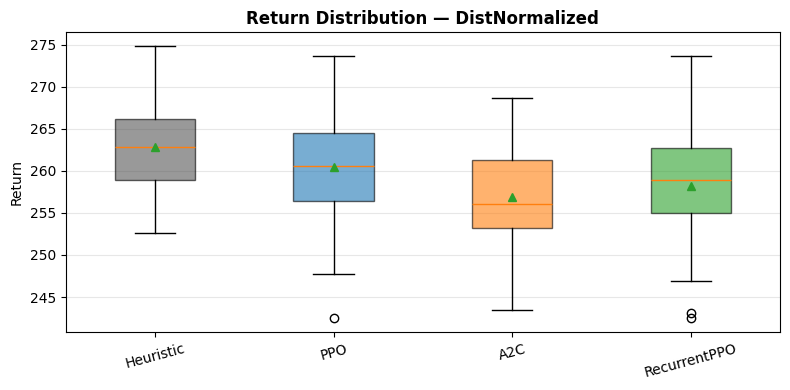

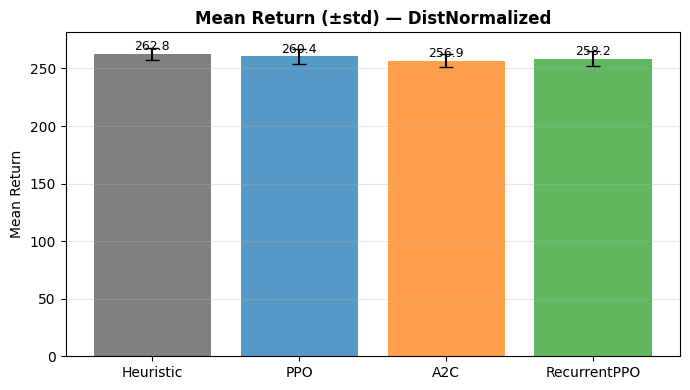

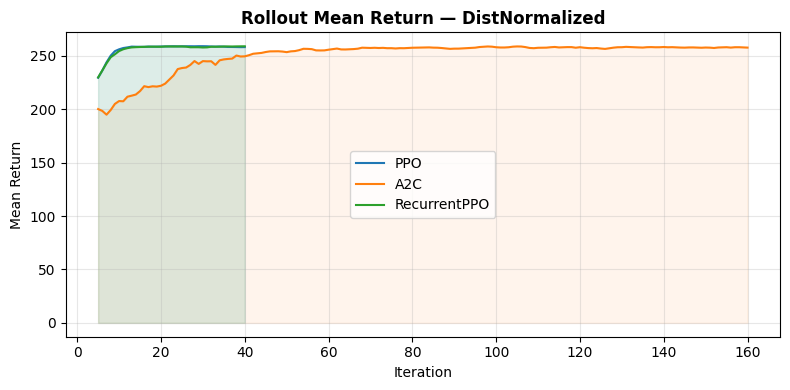

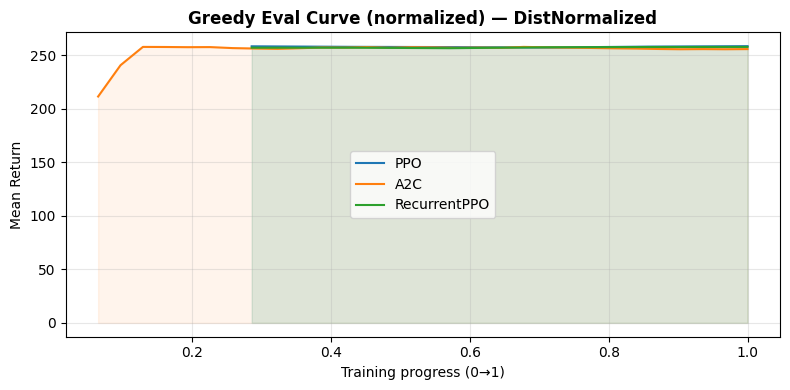

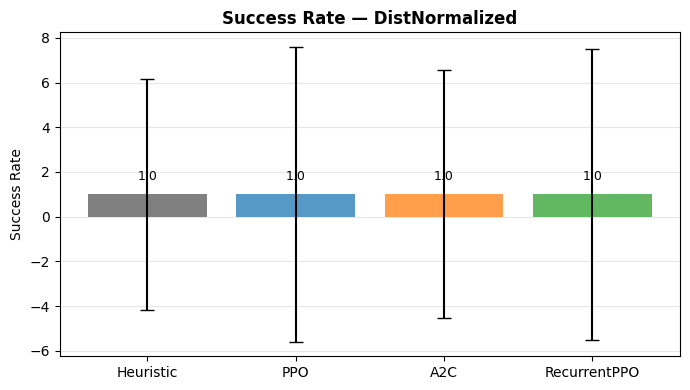


REWARD: CompletionRatio
  [Heuristic] evaluating...
  Heuristic mean_return=240.00 success=1.00
  [PPO] training...
  PPO iter 10/40 | rollout mean return=238.65 | ent_coef=0.0396
  PPO iter 20/40 | rollout mean return=239.57 | ent_coef=0.0281
  PPO iter 30/40 | rollout mean return=239.91 | ent_coef=0.0165
  PPO iter 40/40 | rollout mean return=239.99 | ent_coef=0.0050
  PPO mean_return=240.00 success=1.00
  [A2C] training...
  A2C iter 20/160 | rollout mean return=218.52
  A2C iter 40/160 | rollout mean return=231.27
  A2C iter 60/160 | rollout mean return=236.62
  A2C iter 80/160 | rollout mean return=238.21
  A2C iter 100/160 | rollout mean return=238.49
  A2C iter 120/160 | rollout mean return=238.46
  A2C iter 140/160 | rollout mean return=237.85
  A2C iter 160/160 | rollout mean return=238.49
  A2C mean_return=240.00 success=1.00
  [RecurrentPPO] training...
  RecurrentPPO iter 10/40 | rollout mean return=239.59 | ent_coef=0.0396
  RecurrentPPO iter 20/40 | rollout mean return=2

/tmp/ipykernel_2509/2705059899.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, showmeans=True, patch_artist=True)


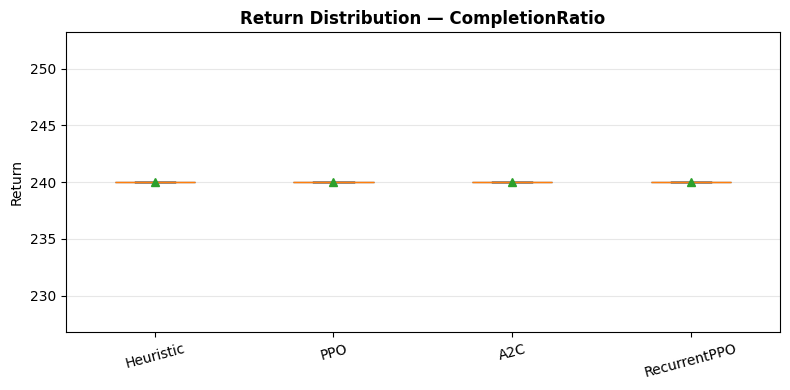

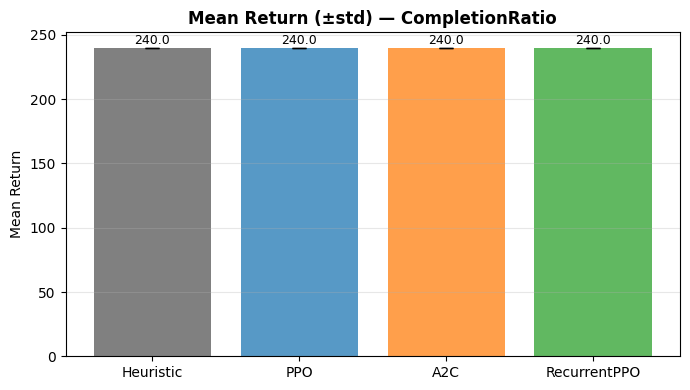

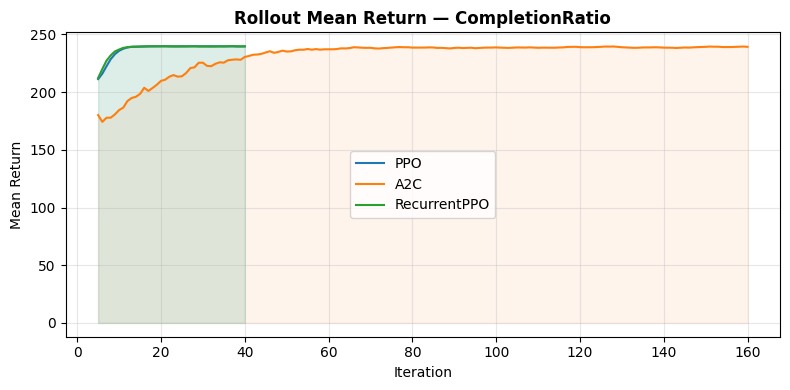

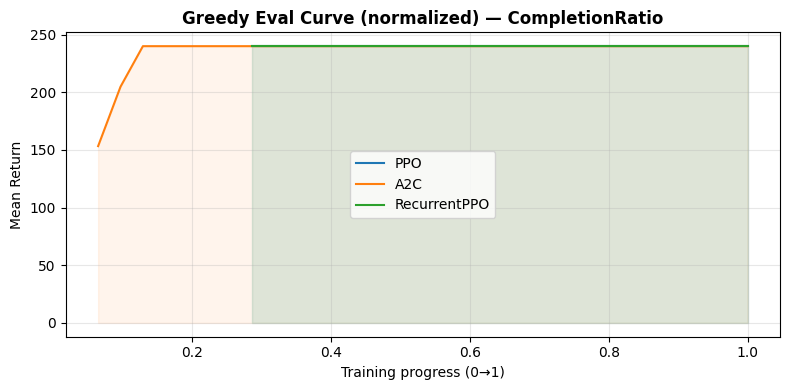

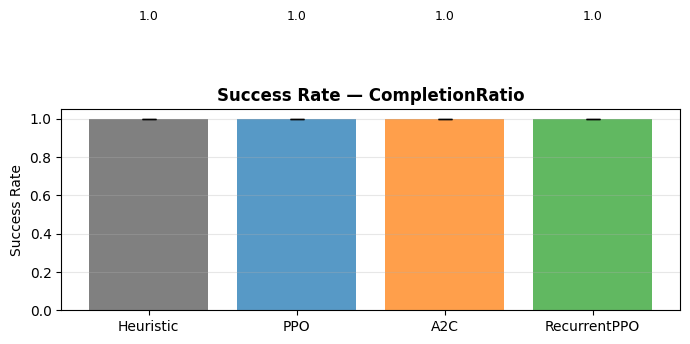


REWARD: BatteryAware
  [Heuristic] evaluating...
  Heuristic mean_return=210.00 success=1.00
  [PPO] training...
  PPO iter 10/40 | rollout mean return=208.59 | ent_coef=0.0396
  PPO iter 20/40 | rollout mean return=209.73 | ent_coef=0.0281
  PPO iter 30/40 | rollout mean return=209.79 | ent_coef=0.0165
  PPO iter 40/40 | rollout mean return=209.39 | ent_coef=0.0050
  PPO mean_return=209.94 success=1.00
  [A2C] training...
  A2C iter 20/160 | rollout mean return=155.75
  A2C iter 40/160 | rollout mean return=197.35
  A2C iter 60/160 | rollout mean return=206.87
  A2C iter 80/160 | rollout mean return=208.65
  A2C iter 100/160 | rollout mean return=208.99
  A2C iter 120/160 | rollout mean return=209.80
  A2C iter 140/160 | rollout mean return=209.39
  A2C iter 160/160 | rollout mean return=208.72
  A2C mean_return=209.90 success=1.00
  [RecurrentPPO] training...
  RecurrentPPO iter 10/40 | rollout mean return=209.18 | ent_coef=0.0396
  RecurrentPPO iter 20/40 | rollout mean return=209.

/tmp/ipykernel_2509/2705059899.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, showmeans=True, patch_artist=True)


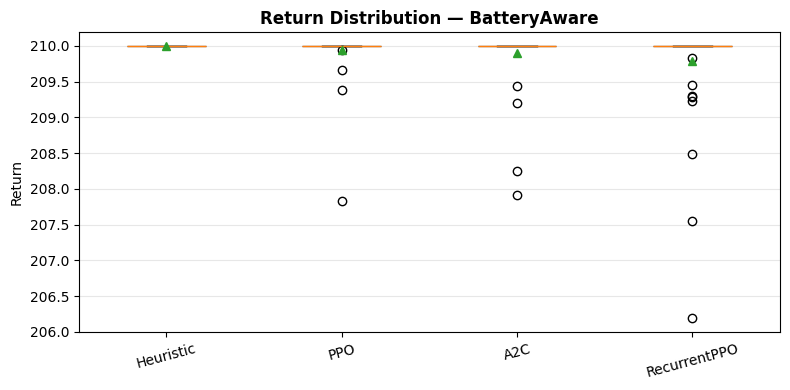

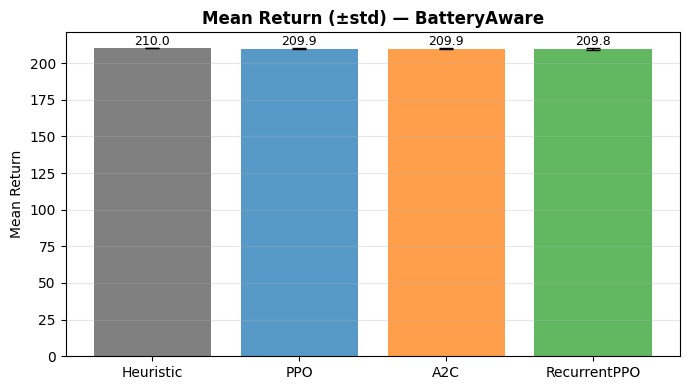

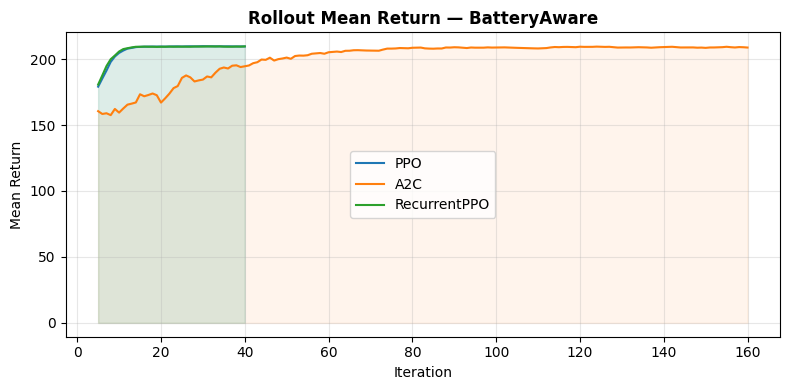

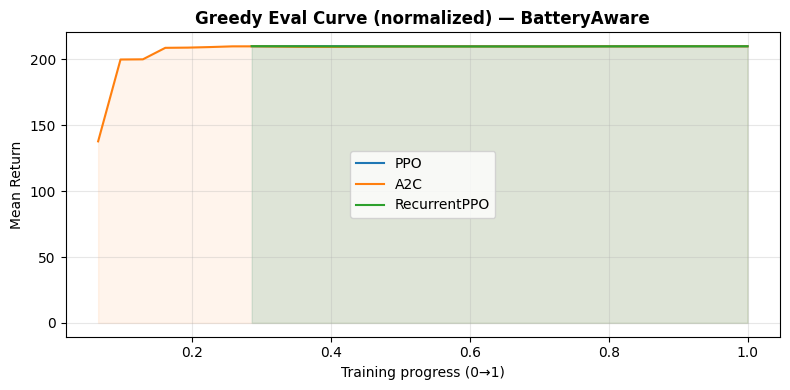

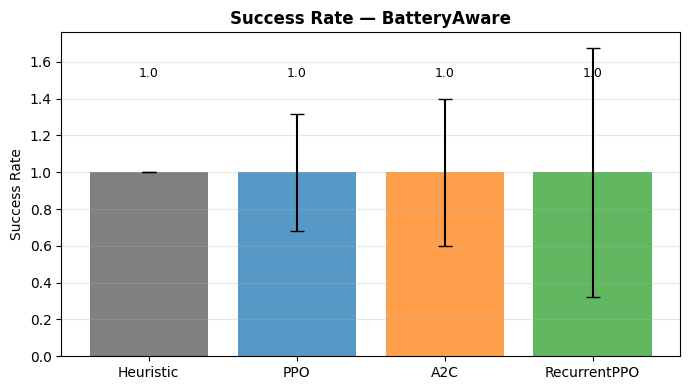


REWARD: TimePressure
  [Heuristic] evaluating...
  Heuristic mean_return=185.00 success=1.00
  [PPO] training...
  PPO iter 10/40 | rollout mean return=184.75 | ent_coef=0.0396
  PPO iter 20/40 | rollout mean return=184.67 | ent_coef=0.0281
  PPO iter 30/40 | rollout mean return=184.76 | ent_coef=0.0165
  PPO iter 40/40 | rollout mean return=184.85 | ent_coef=0.0050
  PPO mean_return=185.00 success=1.00
  [A2C] training...
  A2C iter 20/160 | rollout mean return=152.18
  A2C iter 40/160 | rollout mean return=181.38
  A2C iter 60/160 | rollout mean return=183.97
  A2C iter 80/160 | rollout mean return=183.32
  A2C iter 100/160 | rollout mean return=184.94
  A2C iter 120/160 | rollout mean return=184.11
  A2C iter 140/160 | rollout mean return=184.99
  A2C iter 160/160 | rollout mean return=184.41
  A2C mean_return=185.00 success=1.00
  [RecurrentPPO] training...
  RecurrentPPO iter 10/40 | rollout mean return=183.15 | ent_coef=0.0396
  RecurrentPPO iter 20/40 | rollout mean return=184.

/tmp/ipykernel_2509/2705059899.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, showmeans=True, patch_artist=True)


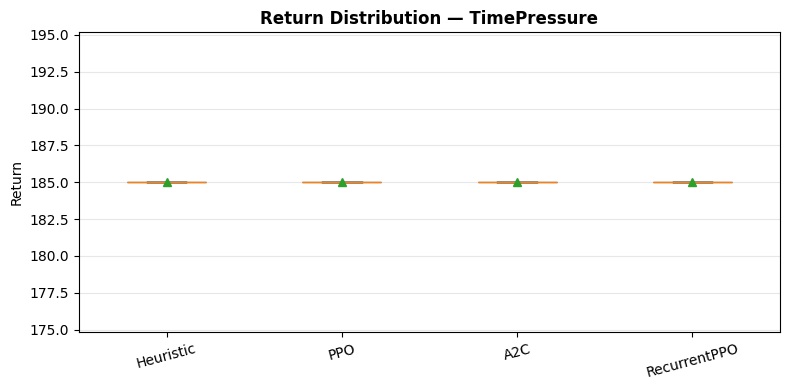

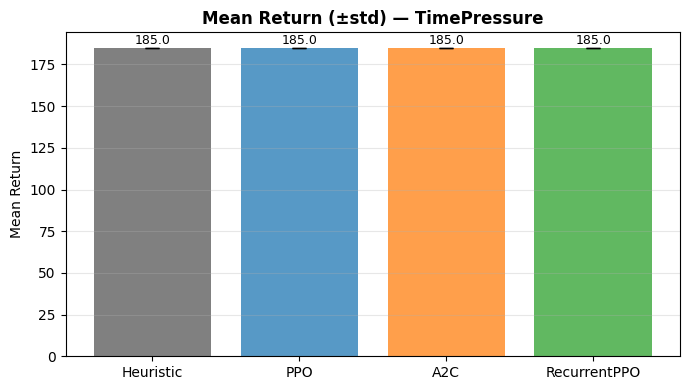

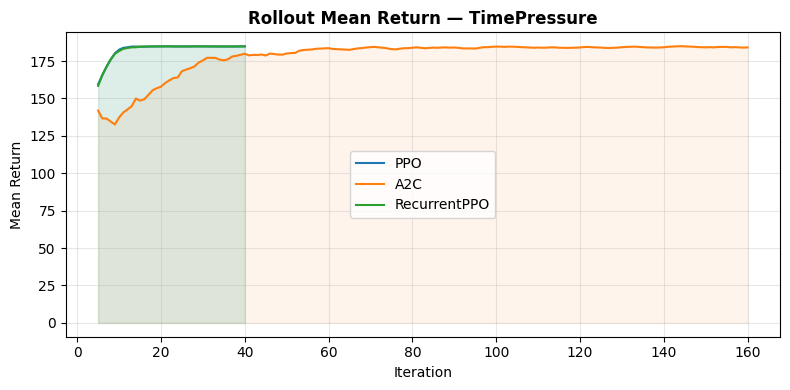

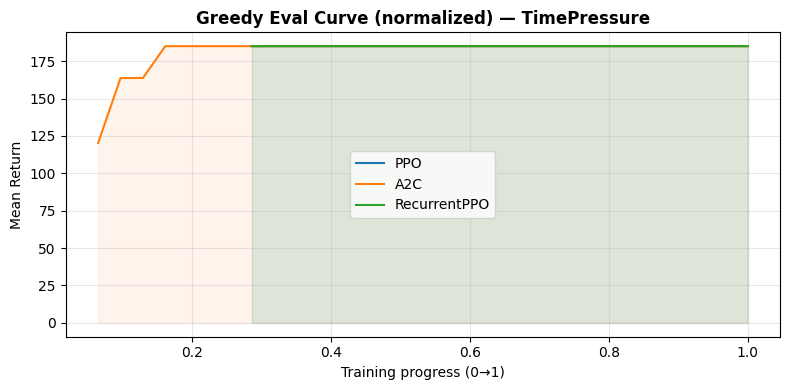

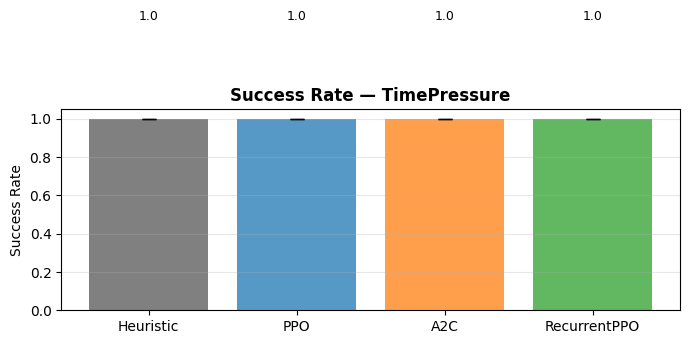


REWARD: RegretBased
  [Heuristic] evaluating...
  Heuristic mean_return=210.00 success=1.00
  [PPO] training...
  PPO iter 10/40 | rollout mean return=209.56 | ent_coef=0.0396
  PPO iter 20/40 | rollout mean return=209.81 | ent_coef=0.0281
  PPO iter 30/40 | rollout mean return=209.74 | ent_coef=0.0165
  PPO iter 40/40 | rollout mean return=209.55 | ent_coef=0.0050
  PPO mean_return=210.00 success=1.00
  [A2C] training...
  A2C iter 20/160 | rollout mean return=150.42
  A2C iter 40/160 | rollout mean return=195.36
  A2C iter 60/160 | rollout mean return=207.93
  A2C iter 80/160 | rollout mean return=208.88
  A2C iter 100/160 | rollout mean return=208.51
  A2C iter 120/160 | rollout mean return=209.27
  A2C iter 140/160 | rollout mean return=208.26
  A2C iter 160/160 | rollout mean return=209.29
  A2C mean_return=210.00 success=1.00
  [RecurrentPPO] training...
  RecurrentPPO iter 10/40 | rollout mean return=209.36 | ent_coef=0.0396
  RecurrentPPO iter 20/40 | rollout mean return=209.4

/tmp/ipykernel_2509/2705059899.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, showmeans=True, patch_artist=True)


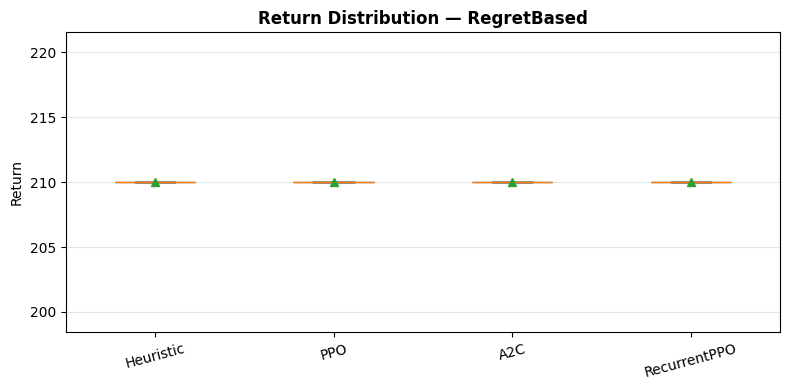

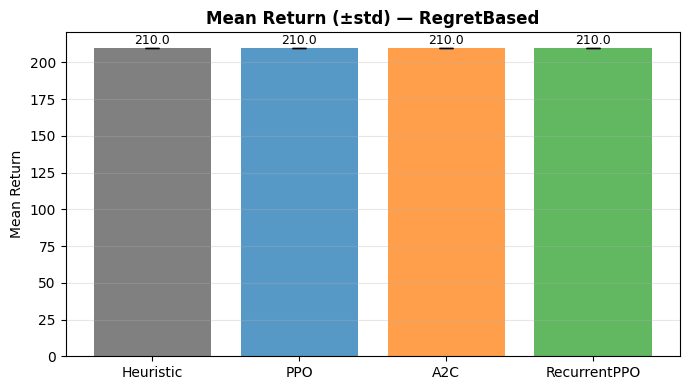

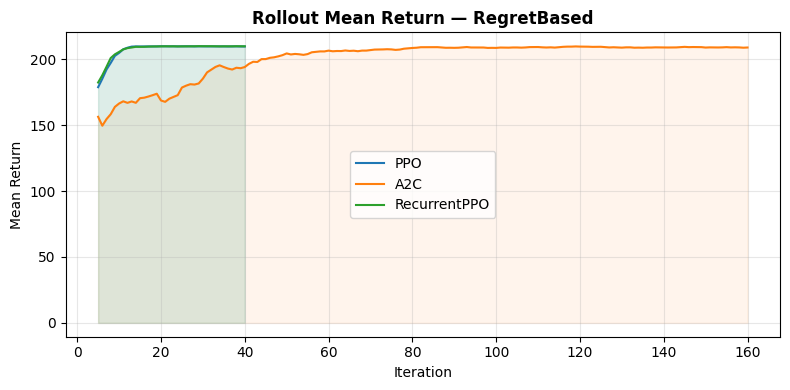

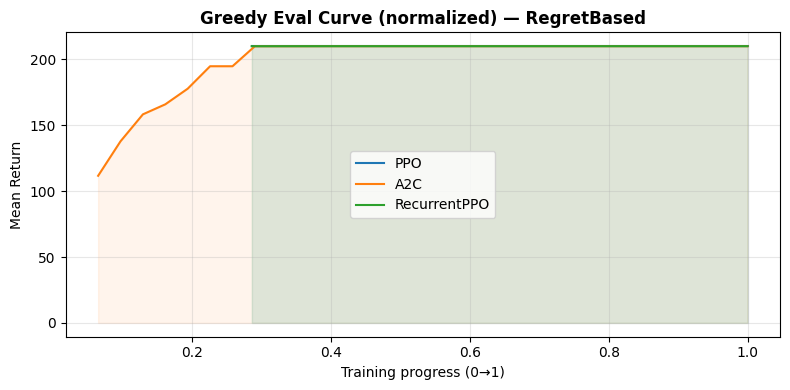

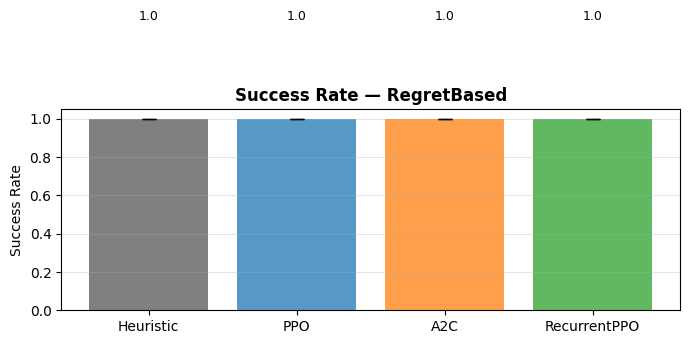


FINAL RESULTS TABLE


,reward_setting,algo,mean_return,std_return,success_rate,mean_customers_served,mean_tardiness,mean_distance
0,BatteryAware,Heuristic,210.000000,0.000000e+00,1.0,5.0,0.0,256.139709
1,BatteryAware,PPO,209.936523,3.185365e-01,1.0,5.0,0.0,275.442889
2,BatteryAware,A2C,209.896130,3.989098e-01,1.0,5.0,0.0,279.582360
3,BatteryAware,RecurrentPPO,209.786654,6.766405e-01,1.0,5.0,0.0,300.221374
4,CompletionRatio,Heuristic,240.000000,2.871026e-14,1.0,5.0,0.0,245.980694
5,CompletionRatio,PPO,240.000000,2.871026e-14,1.0,5.0,0.0,290.218809
6,CompletionRatio,A2C,240.000000,2.871026e-14,1.0,5.0,0.0,276.558567
7,CompletionRatio,RecurrentPPO,240.000000,2.871026e-14,1.0,5.0,0.0,297.642592
8,DistNormalized,Heuristic,262.801172,5.176740e+00,1.0,5.0,0.0,247.559075
9,DistNormalized,PPO,260.445176,6.588251e+00,1.0,5.0,0.0,270.208159



=== Pivot: mean_return per reward × algo ===


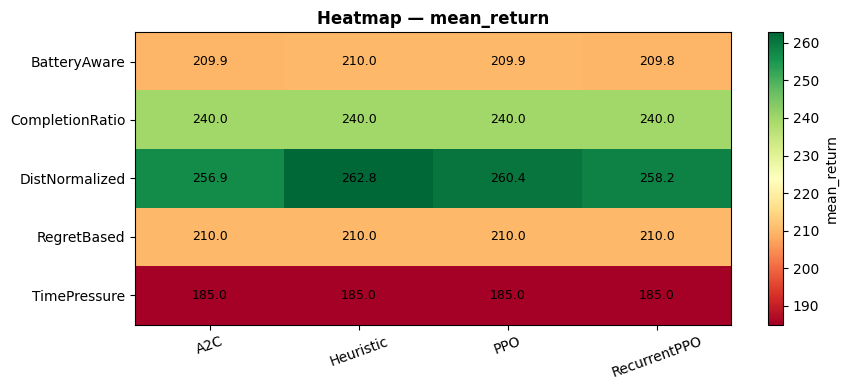

algo,A2C,Heuristic,PPO,RecurrentPPO
reward_setting,,,,
BatteryAware,209.896130,210.000000,209.936523,209.786654
CompletionRatio,240.000000,240.000000,240.000000,240.000000
DistNormalized,256.910261,262.801172,260.445176,258.247412
RegretBased,210.000000,210.000000,210.000000,210.000000
TimePressure,185.000000,185.000000,185.000000,185.000000



=== Pivot: success_rate per reward × algo ===


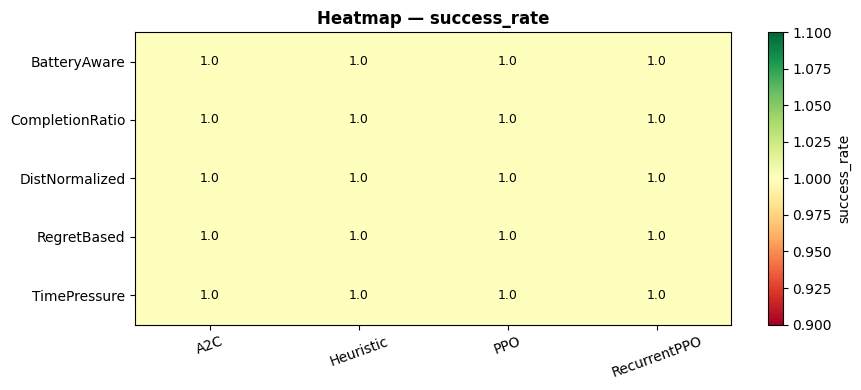

algo,A2C,Heuristic,PPO,RecurrentPPO
reward_setting,,,,
BatteryAware,1.0,1.0,1.0,1.0
CompletionRatio,1.0,1.0,1.0,1.0
DistNormalized,1.0,1.0,1.0,1.0
RegretBased,1.0,1.0,1.0,1.0
TimePressure,1.0,1.0,1.0,1.0



=== Average mean_return across ALL reward settings ===
algo
Heuristic       221.560234
PPO             221.076340
RecurrentPPO    220.606813
A2C             220.361278


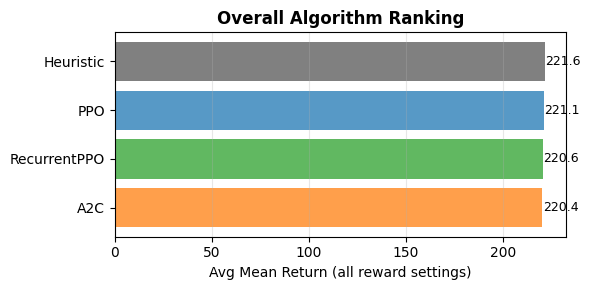


Saved: uav_rl_results.csv


In [ ]:
# ============================================================
# CELL 8 — Experiment Runner + Final Comparison Plots
# ============================================================

# ---- Reward settings to compare ----
REWARD_SETTINGS = [
    {
        "name": "DistNormalized",
        "overrides": dict(reward_mode="dist_normalized",
                          w_service=30.0, w_complete=60.0,
                          w_infeasible=10.0, w_dist_bonus=15.0,
                          w_tardiness=0.2)
    },
    {
        "name": "CompletionRatio",
        "overrides": dict(reward_mode="completion_ratio",
                          w_service=25.0, w_complete=60.0,
                          w_infeasible=10.0, w_tardiness=0.2)
    },
    {
        "name": "BatteryAware",
        "overrides": dict(reward_mode="battery_aware",
                          w_service=30.0, w_complete=60.0,
                          w_infeasible=10.0, w_battery_pen=6.0,
                          battery_low_thresh=0.25, w_tardiness=0.2)
    },
    {
        "name": "TimePressure",
        "overrides": dict(reward_mode="time_pressure",
                          w_service=25.0, w_complete=60.0,
                          w_infeasible=10.0, w_time_late_mult=3.0,
                          w_tardiness=0.2)
    },
    {
        "name": "RegretBased",
        "overrides": dict(reward_mode="regret_based",
                          w_service=30.0, w_complete=60.0,
                          w_infeasible=10.0, w_regret=4.0,
                          w_tardiness=0.2)
    },
]

# ---- Training hyperparameters (tune here) ----
PPO_ITERS          = 40      # iterations per PPO run
A2C_ITERS          = 160     # iterations per A2C run (shorter per-iter)
RPPO_ITERS         = 40      # iterations per RecurrentPPO run
EVAL_EPISODES      = 50      # final evaluation episodes per algo
EVAL_EVERY         = 5       # eval curve frequency (iters)
CURVE_EVAL_EPS     = 10      # episodes per eval point on curve


def run_experiment(setting: dict, seed: int = 0):
    name       = setting["name"]
    overrides  = setting["overrides"]
    env_fn     = lambda: make_env(overrides)

    print(f"\n{'='*70}")
    print(f"REWARD: {name}")
    print(f"{'='*70}")

    # ---------- Heuristic ----------
    print("  [Heuristic] evaluating...")
    heur_summary, heur_returns = evaluate_policy(
        env_fn, heur.act, episodes=EVAL_EPISODES, seed=seed)
    print(f"  Heuristic mean_return={heur_summary['mean_return']:.2f} "
          f"success={heur_summary['success_rate']:.2f}")

    # ---------- PPO ----------
    print("  [PPO] training...")
    ppo_trainer = PPOTrainer(
        env_fn,
        iters=PPO_ITERS,
        steps_per_iter=2048,
        hidden_dim=128, lr=3e-4,
        ent_coef=0.05, ent_coef_end=0.005,
        normalise_rewards=True, seed=seed + 10,
    ).train(eval_every_iters=EVAL_EVERY, eval_episodes=CURVE_EVAL_EPS)

    ppo_summary, ppo_returns = evaluate_policy(
        env_fn,
        lambda e, o, i: ppo_trainer.act(o, i),
        episodes=EVAL_EPISODES, seed=seed + 2)
    print(f"  PPO mean_return={ppo_summary['mean_return']:.2f} "
          f"success={ppo_summary['success_rate']:.2f}")

    # ---------- A2C ----------
    print("  [A2C] training...")
    a2c_trainer = A2CTrainer(
        env_fn,
        iters=A2C_ITERS,
        steps_per_iter=512,
        hidden_dim=128, lr=7e-4,
        normalise_rewards=True, seed=seed + 20,
    ).train(eval_every_iters=EVAL_EVERY, eval_episodes=CURVE_EVAL_EPS)

    a2c_summary, a2c_returns = evaluate_policy(
        env_fn,
        lambda e, o, i: a2c_trainer.act(o, i),
        episodes=EVAL_EPISODES, seed=seed + 3)
    print(f"  A2C mean_return={a2c_summary['mean_return']:.2f} "
          f"success={a2c_summary['success_rate']:.2f}")

    # ---------- RecurrentPPO ----------
    print("  [RecurrentPPO] training...")
    rppo_trainer = RecurrentPPOTrainer(
        env_fn,
        iters=RPPO_ITERS,
        steps_per_iter=2048,
        chunk_len=16,
        hidden_dim=128, lr=3e-4,
        ent_coef=0.05, ent_coef_end=0.005,
        normalise_rewards=True, seed=seed + 30,
    ).train(eval_every_iters=EVAL_EVERY, eval_episodes=CURVE_EVAL_EPS)

    rppo_summary, rppo_returns = evaluate_policy(
        env_fn,
        lambda e, o, i: rppo_trainer.act(o, i),
        episodes=EVAL_EPISODES, seed=seed + 4)
    print(f"  RecurrentPPO mean_return={rppo_summary['mean_return']:.2f} "
          f"success={rppo_summary['success_rate']:.2f}")

    # ===================== Per-reward plots =====================

    # 1) Boxplot: return distribution comparison
    boxplot_compare(
        f"Return Distribution — {name}",
        {"Heuristic": heur_returns,
         "PPO":        ppo_returns,
         "A2C":        a2c_returns,
         "RecurrentPPO": rppo_returns}
    )

    # 2) Bar: mean return with std error bars
    bar_compare(
        f"Mean Return (±std) — {name}",
        {"Heuristic":   heur_summary,
         "PPO":         ppo_summary,
         "A2C":         a2c_summary,
         "RecurrentPPO":rppo_summary},
        metric="mean_return"
    )

    # 3) Learning curves — rollout mean return per algo
    plot_learning_curves(
        {
            "PPO":         (ppo_trainer.rollout_iter,  ppo_trainer.rollout_mean_return),
            "A2C":         (a2c_trainer.rollout_iter,  a2c_trainer.rollout_mean_return),
            "RecurrentPPO":(rppo_trainer.rollout_iter, rppo_trainer.rollout_mean_return),
        },
        title=f"Rollout Mean Return — {name}",
        xlabel="Iteration", smooth_k=5
    )

    # 4) Eval curves — greedy eval (normalized x so algos are comparable)
    eval_curves = {}
    if ppo_trainer.eval_iters:
        eval_curves["PPO"] = (
            normalize_x(ppo_trainer.eval_iters), ppo_trainer.eval_mean_returns)
    if a2c_trainer.eval_iters:
        eval_curves["A2C"] = (
            normalize_x(a2c_trainer.eval_iters), a2c_trainer.eval_mean_returns)
    if rppo_trainer.eval_iters:
        eval_curves["RecurrentPPO"] = (
            normalize_x(rppo_trainer.eval_iters), rppo_trainer.eval_mean_returns)
    if eval_curves:
        plot_learning_curves(
            eval_curves,
            title=f"Greedy Eval Curve (normalized) — {name}",
            xlabel="Training progress (0→1)", smooth_k=3
        )

    # 5) Success rate bar
    bar_compare(
        f"Success Rate — {name}",
        {"Heuristic":   heur_summary,
         "PPO":         ppo_summary,
         "A2C":         a2c_summary,
         "RecurrentPPO":rppo_summary},
        metric="success_rate"
    )

    # return everything for the final aggregate table
    summaries = {
        "Heuristic":    heur_summary,
        "PPO":          ppo_summary,
        "A2C":          a2c_summary,
        "RecurrentPPO": rppo_summary,
    }
    returns = {
        "Heuristic":    heur_returns,
        "PPO":          ppo_returns,
        "A2C":          a2c_returns,
        "RecurrentPPO": rppo_returns,
    }
    return summaries, returns


# ============================================================
# RUN ALL REWARD SETTINGS
# ============================================================
ALL_ROWS   = []
ALL_RETURNS= {}   # {reward_name: {algo: returns_array}}

for idx, setting in enumerate(REWARD_SETTINGS):
    summaries, returns_dict = run_experiment(setting, seed=1000 + 100 * idx)
    ALL_RETURNS[setting["name"]] = returns_dict
    for algo, summ in summaries.items():
        row = {"reward_setting": setting["name"], "algo": algo}
        row.update(summ)
        ALL_ROWS.append(row)

df = pd.DataFrame(ALL_ROWS)

# ============================================================
# FINAL AGGREGATE COMPARISON
# ============================================================
print("\n" + "="*70)
print("FINAL RESULTS TABLE")
print("="*70)
display(df[["reward_setting","algo","mean_return","std_return",
            "success_rate","mean_customers_served",
            "mean_tardiness","mean_distance"]]
        .sort_values(["reward_setting","mean_return"], ascending=[True, False])
        .reset_index(drop=True))

print("\n=== Pivot: mean_return per reward × algo ===")
pivot = pivot_heatmap(df, metric="mean_return")
display(pivot)

print("\n=== Pivot: success_rate per reward × algo ===")
pivot_sr = pivot_heatmap(df, metric="success_rate")
display(pivot_sr)

# ---- Grand summary: average rank across reward settings ----
print("\n=== Average mean_return across ALL reward settings ===")
avg = df.groupby("algo")["mean_return"].mean().sort_values(ascending=False)
print(avg.to_string())
fig, ax = plt.subplots(figsize=(6, 3))
colors = [ALGO_COLORS.get(l, "#aaaaaa") for l in avg.index]
ax.barh(avg.index[::-1], avg.values[::-1], color=colors[::-1], alpha=0.75)
ax.set_xlabel("Avg Mean Return (all reward settings)")
ax.set_title("Overall Algorithm Ranking", fontweight="bold")
ax.grid(axis="x", alpha=0.3)
for i, (lbl, val) in enumerate(zip(avg.index[::-1], avg.values[::-1])):
    ax.text(val + 0.2, i, f"{val:.1f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

# ---- Save results ----
df.to_csv("uav_rl_results.csv", index=False)
print("\nSaved: uav_rl_results.csv")